# Data Science in Cyber Security - Concluding Assignment
*Ilay Nadler (326218617)*

July 2026

In [ ]:
# --- Setup and Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef, roc_auc_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Set fixed random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# --- Corrected Header Alignment & Missing Value Names ---
import pandas as pd

try:
    # 1. Load the headers from the text file
    with open('ddos_column_headers.txt', 'r') as file:
        raw_text = file.read().strip()
        feature_names = [name.strip() for name in raw_text.split(',')]

    # 2. FIX THE MISMATCH: Insert an 'ID' column at the very beginning (index 0)
    feature_names.insert(0, 'ID_Column')
    print(f"Successfully adjusted to {len(feature_names)} feature names.")

    # 3. Read the actual data file
    df = pd.read_csv('modified_dataset.csv', header=None)

    # 4. Map the headers to the columns
    if len(feature_names) == len(df.columns):
        df.columns = feature_names
        print("Data loaded and headers assigned successfully.")
    else:
        print(f"Warning: Column mismatch! Data has {len(df.columns)} columns, but found {len(feature_names)} headers.")

except FileNotFoundError as e:
    print(f"File not found error: {e}. Please ensure both files are uploaded.")
    df = pd.DataFrame()

# 5. Exploratory checks & Printing Missing Value Feature Names
if not df.empty:
    print(f"\nDataset Shape: {df.shape}")

    print("\n--- Missing Values Analysis ---")
    missing_counts = df.isnull().sum()
    missing_features = missing_counts[missing_counts > 0]

    if not missing_features.empty:
        for feature_name, count in missing_features.items():
            print(f"Feature: '{feature_name}' has {count} missing values.")
    else:
        print("No missing values found.")

    # We can also drop the useless 'ID_Column' now so it doesn't mess up our ML models
    df = df.drop(columns=['ID_Column'])
    print("\nDropped 'ID_Column' as it is not a predictive feature.")

Successfully adjusted to 80 feature names.
Data loaded and headers assigned successfully.

Dataset Shape: (225745, 80)

--- Missing Values Analysis ---
Feature: 'Flow Bytes/s' has 4 missing values.

Dropped 'ID_Column' as it is not a predictive feature.


Flow Bytes/s is missing whenever the Flow Duration is 0. We may choose to fill it with 0, indicating that there is no byte flow. However, since we do not know for sure how that will imply along with the rest of the data, and since it is only 4 instances, we drop them.

In [ ]:
# --- Handling Missing & Infinite Values ---
import numpy as np

print("--- Pre-cleaning Shape ---")
print(df.shape)

# 1. Address the missing values found in EDA
# Since it's only 4 rows in 'Flow Packets/s', dropping them is safest.
df = df.dropna()

# 2. Hidden Preprocessing: Division by zero often creates 'Infinity' in these columns too.
# Let's replace any infinite values with NaN, then drop them just to be safe.
# This prevents Neural Networks from crashing during training.
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna()

print("\n--- Post-cleaning Shape ---")
print(df.shape)
print("\nMissing values remaining:", df.isnull().sum().sum())

--- Pre-cleaning Shape ---
(225745, 79)

--- Post-cleaning Shape ---
(225711, 79)

Missing values remaining: 0


We can see that more than 4 rows have dropped. It is due to the second check of infinite values.

In [ ]:
# --- Dataset Preview & Feature Overview ---

if not df.empty:
    print("="*50)
    print("1. COMPLETE FEATURE LIST")
    print("="*50)
    # Extracting and printing all feature names in a readable format
    all_features = df.columns.tolist()

    # Print in chunks of 5 for better readability in the Colab output
    for i in range(0, len(all_features), 5):
        print(", ".join(all_features[i:i+5]))

    print("\n" + "="*50)
    print("2. DATA TYPES & MEMORY USAGE")
    print("="*50)
    # df.info() fulfills the syllabus requirement to inspect feature types
    # We use verbose=True and show_counts=True to ensure it prints everything
    df.info(verbose=True, show_counts=True)

    print("\n" + "="*50)
    print("3. DATASET PREVIEW (FIRST 5 ROWS)")
    print("="*50)
    # Display the first 5 rows. In Colab, leaving this at the end of the cell
    # will render it as a nice interactive HTML table!
    display(df.head())

1. COMPLETE FEATURE LIST
Destination Port, Flow Duration, Total Fwd Packets, Total Backward Packets, Total Length of Fwd Packets
Total Length of Bwd Packets, Fwd Packet Length Max, Fwd Packet Length Min, Fwd Packet Length Mean, Fwd Packet Length Std
Bwd Packet Length Max, Bwd Packet Length Min, Bwd Packet Length Mean, Bwd Packet Length Std, Flow Bytes/s
Flow Packets/s, Flow IAT Mean, Flow IAT Std, Flow IAT Max, Flow IAT Min
Fwd IAT Total, Fwd IAT Mean, Fwd IAT Std, Fwd IAT Max, Fwd IAT Min
Bwd IAT Total, Bwd IAT Mean, Bwd IAT Std, Bwd IAT Max, Bwd IAT Min
Fwd PSH Flags, Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, Fwd Header Length
Bwd Header Length, Fwd Packets/s, Bwd Packets/s, Min Packet Length, Max Packet Length
Packet Length Mean, Packet Length Std, Packet Length Variance, FIN Flag Count, SYN Flag Count
RST Flag Count, PSH Flag Count, ACK Flag Count, URG Flag Count, CWE Flag Count
ECE Flag Count, Down/Up Ratio, Average Packet Size, Avg Fwd Segment Size, Avg Bwd Segment Size
Fwd He

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


### Exploratory Data Analysis: Redundancy, Distributions, and Outliers

Before looking at class balance and correlation, we check for the cheaper, more mechanical
issues first: duplicate column names, constant columns, exact duplicate-value columns,
feature distributions, and outliers.

In [ ]:
# --- Duplicate Names, Constant Features, Duplicate-Value Features ---
print("="*50)
print("DUPLICATE COLUMN NAMES")
print("="*50)

# The raw header file contains 'Fwd Header Length' twice, a known quirk of this
# CICFlowMeter export. Because df.columns was assigned directly from a Python list,
# pandas allows the duplicate name silently -- df['Fwd Header Length'] would return
# a 2-column DataFrame instead of a Series, which can silently break later code
# (e.g. scaling, correlation-by-name lookups, single-column selection).
name_counts = df.columns.value_counts()
duplicate_names = name_counts[name_counts > 1]
print(f"Duplicate column names found: {len(duplicate_names)}")
if not duplicate_names.empty:
    print(duplicate_names)
    # Rename the second occurrence (pandas' own convention: '.1' suffix) so every
    # later per-column operation is unambiguous.
    df.columns = pd.io.common.dedup_names(df.columns, is_potential_multiindex=False)
    print("Renamed duplicate to keep columns unique for downstream operations.")

print("\n" + "="*50)
print("CONSTANT (SINGLE-VALUE) FEATURES")
print("="*50)
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print(f"Constant columns found: {len(constant_cols)}")
print(constant_cols)
print("\nCybersecurity Context: a feature that never varies (e.g. an always-zero flag)")
print("carries zero information for any model and only adds dead weight to an edge")
print("deployment, so these are safe to drop outright.")

print("\n" + "="*50)
print("EXACT DUPLICATE-VALUE FEATURES")
print("="*50)
# Different from the Spearman correlation check later: this looks for columns whose
# VALUES are identical row-for-row (not just highly correlated), which is a stronger
# and cheaper redundancy signal to act on first.
seen = {}
for col in df.columns:
    key = tuple(df[col].values[:2000])  # sample first for speed
    seen.setdefault(key, []).append(col)

duplicate_value_groups = []
for cols in seen.values():
    if len(cols) > 1:
        base = df[cols[0]]
        confirmed = [c for c in cols[1:] if df[c].equals(base)]
        if confirmed:
            duplicate_value_groups.append((cols[0], confirmed))

print(f"Duplicate-value column groups found: {len(duplicate_value_groups)}")
for original, dupes in duplicate_value_groups:
    print(f"  '{original}' duplicated by {dupes}")

# Consolidate everything this cell found into one drop-list other cells can reuse
exact_redundant_features = list(constant_cols) + [c for _, dupes in duplicate_value_groups for c in dupes]
exact_redundant_features = sorted(set(exact_redundant_features))
print(f"\nTotal exact-redundant features flagged for removal: {len(exact_redundant_features)}")


In [ ]:
# --- Feature Distributions ---
print("="*50)
print("FEATURE DISTRIBUTIONS")
print("="*50)

target_col = df.columns[-1]
numeric_df = df.select_dtypes(include=[np.number])
dist_cols = [c for c in numeric_df.columns if c != target_col]

# Plot in batches so the grid stays readable
batch_size = 12
for start in range(0, len(dist_cols), batch_size):
    batch = dist_cols[start:start + batch_size]
    n_cols = 4
    n_rows = int(np.ceil(len(batch) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    for ax, col in zip(axes, batch):
        sns.histplot(df[col], bins=40, kde=False, ax=ax, color='steelblue')
        ax.set_title(col, fontsize=9)
        ax.set_xlabel("")
    for ax in axes[len(batch):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print("\nCybersecurity Context: most flow-based features are heavily right-skewed with")
print("long tails. Those tails are frequently the attack signal itself (burst traffic),")
print("not noise, so they are not clipped or log-transformed away by default.")


In [ ]:
# --- Outlier Analysis (IQR Method) ---
print("="*50)
print("OUTLIER ANALYSIS (IQR METHOD)")
print("="*50)

target_col = df.columns[-1]
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=[target_col], errors='ignore')

outlier_summary = []
for col in numeric_df.columns:
    q1, q3 = numeric_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((numeric_df[col] < lower) | (numeric_df[col] > upper)).sum()
    pct_outliers = 100 * n_outliers / len(numeric_df)
    outlier_summary.append((col, n_outliers, round(pct_outliers, 2)))

outlier_df = pd.DataFrame(
    outlier_summary, columns=['Feature', 'Outlier_Count', 'Outlier_Pct']
).sort_values('Outlier_Pct', ascending=False)
display(outlier_df.head(15))

# Visualize the features with the highest outlier proportion, split by class
top_outlier_cols = outlier_df['Feature'].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, top_outlier_cols):
    sns.boxplot(x=df[target_col].astype(str), y=df[col], hue=df[target_col].astype(str),
                ax=ax, palette='Set2', legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Normal (0) vs Attack (1)')
plt.tight_layout()
plt.show()

print("\nCybersecurity Context: outliers in flow-volume and inter-arrival-time features are")
print("expected during DDoS bursts -- they are retained rather than removed, since clipping")
print("them would erase exactly the signal that separates an attack flow from benign traffic.")


1. CLASS IMBALANCE (PREVALENCE)
Target column identified exactly as: 'Label'



/tmp/ipykernel_18128/1299271826.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=target_col, data=df, palette='viridis')


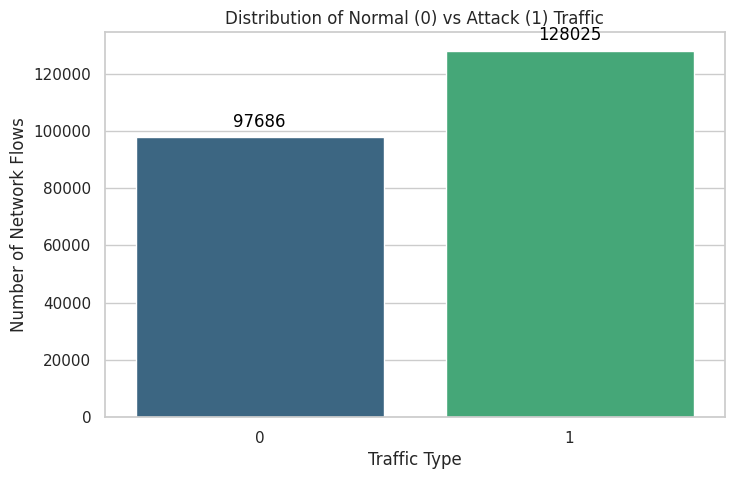


Class Prevalence:
Label
1    56.72
0    43.28
Name: proportion, dtype: object%

Cybersecurity Context: Notice if the dataset accurately reflects real-world edge networks, where benign traffic should massively outweigh attacks.


In [ ]:
# --- Class Imbalance Analysis (Corrected) ---
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

print("="*50)
print("1. CLASS IMBALANCE (PREVALENCE)")
print("="*50)

# BULLETPROOF FIX: Automatically grab the very last column name
# (which is the target variable in the UNSW dataset) instead of guessing the spelling.
target_col = df.columns[-1]
print(f"Target column identified exactly as: '{target_col}'\n")

plt.figure(figsize=(8, 5))

# Pass the exact column name to seaborn
ax = sns.countplot(x=target_col, data=df, palette='viridis')
plt.title(f'Distribution of Normal (0) vs Attack (1) Traffic')
plt.xlabel('Traffic Type')
plt.ylabel('Number of Network Flows')

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

# Calculate and print exact prevalence
prevalence = df[target_col].value_counts(normalize=True) * 100
print(f"\nClass Prevalence:\n{prevalence.round(2).astype(str)}%")
print("\nCybersecurity Context: Notice if the dataset accurately reflects real-world edge networks, where benign traffic should massively outweigh attacks.")

The prevlenace check above is a significant red flag. In the modified dataset the paper's model was trained on, there are more attack samples than normal ones. It the reverse of an authentic IDS situation.

We see later on how that will affect performances on realstically balanced test sets.

2. FEATURE REDUNDANCY (SPEARMAN CORRELATION)


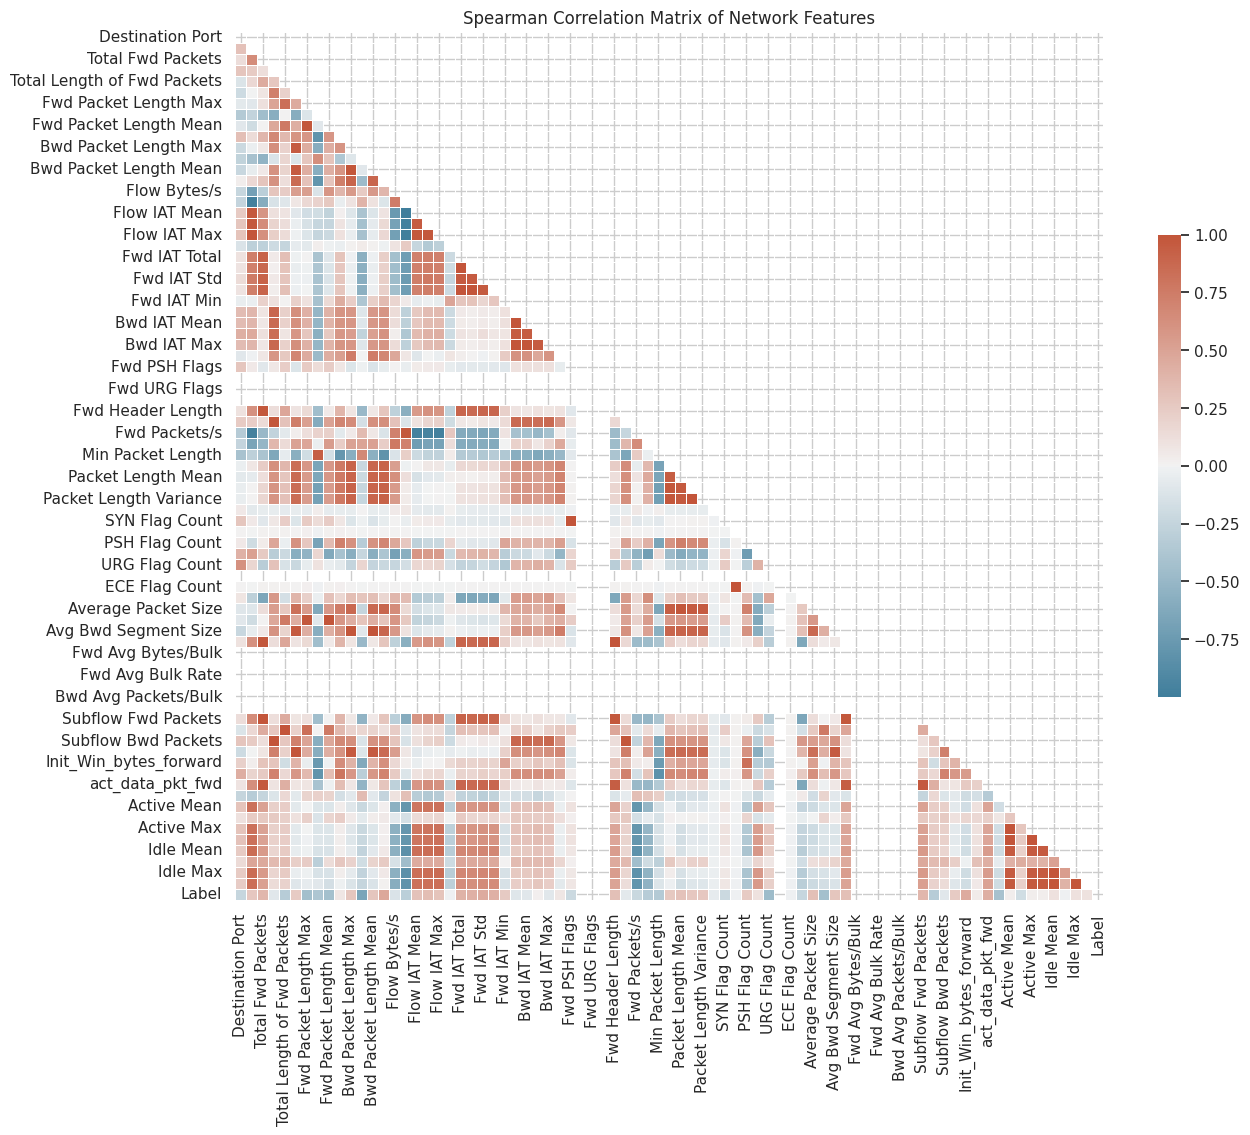


Found 38 highly redundant features.
Features to consider dropping to make the edge model lightweight:
['Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'act_data_pkt_fwd', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Idle Min']


In [ ]:
# --- Correlation Analysis (Spotting Redundancy) ---
import numpy as np

print("="*50)
print("2. FEATURE REDUNDANCY (SPEARMAN CORRELATION)")
print("="*50)

# Select only numeric features for correlation
numeric_df = df.select_dtypes(include=[np.number])

# We use Spearman correlation because network features often have non-linear/monotonic relationships
corr_matrix = numeric_df.corr(method='spearman')

plt.figure(figsize=(14, 12))
# Only plot the lower triangle of the matrix to make it readable
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title("Spearman Correlation Matrix of Network Features")
plt.show()

# Identify highly correlated pairs (>0.9 or <-0.9) to tackle redundancy
# This directly fulfills the syllabus requirement to spot redundancy
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant_features = [column for column in upper.columns if any(upper[column].abs() > 0.90)]

print(f"\nFound {len(redundant_features)} highly redundant features.")
print(f"Features to consider dropping to make the edge model lightweight:\n{redundant_features}")

In [ ]:
# --- Feature Engineering & Preprocessing ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

print("="*50)
print("FEATURE ENGINEERING & SCALING")
print("="*50)

if not df.empty:
    # --- SAFETY CATCH FOR REDUNDANT FEATURES ---
    if 'redundant_features' not in locals() and 'redundant_features' not in globals():
        # SELF-HEALING FIX: instead of silently defaulting to an empty list (which
        # previously caused this cell to train on all 78 features even when a prior
        # cell had already found 38 redundant ones), recompute it here so the drop
        # always happens regardless of cell execution order.
        print("Notice: 'redundant_features' not found in memory. Recomputing it now so")
        print("the redundancy reduction is applied regardless of cell run order.")
        _numeric_df = df.select_dtypes(include=[np.number])
        _corr_matrix = _numeric_df.corr(method='spearman')
        _upper = _corr_matrix.where(np.triu(np.ones(_corr_matrix.shape), k=1).astype(bool))
        redundant_features = [c for c in _upper.columns if any(_upper[c].abs() > 0.90)]

    # Also fold in the exact constant / duplicate-value features identified earlier,
    # if that cell has already run in this session.
    if 'exact_redundant_features' in globals():
        redundant_features = sorted(set(redundant_features) | set(exact_redundant_features))

    print(f"Dropping {len(redundant_features)} redundant features before training.")

    # 1. Drop redundant features
    df_engineered = df.drop(columns=redundant_features, errors='ignore')

    # 2. BULLETPROOF SEPARATION: Grab the last column dynamically as the target
    target_col = df_engineered.columns[-1]
    print(f"Target column identified as: '{target_col}'")

    X = df_engineered.drop(columns=[target_col])
    y = df_engineered[target_col]

    # 3. One-Hot Encode Categorical Variables
    categorical_cols = X.select_dtypes(include=['object']).columns
    print(f"Encoding categorical columns: {list(categorical_cols)}")
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    # 4. Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

    # 5. Feature Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 6. RNN Reshaping
    X_train_rnn = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
    X_test_rnn = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

    print(f"\nFinal Baseline (Random Forest) training shape: {X_train_scaled.shape}")
    print(f"Final RNN (Edge-Detect) training shape: {X_train_rnn.shape}")

FEATURE ENGINEERING & SCALING
Notice: 'redundant_features' list not found in memory. Defaulting to an empty list.
(If you wanted to drop features, ensure you run the Correlation EDA block first!)
Target column identified as: 'Label'
Encoding categorical columns: []

Final Baseline (Random Forest) training shape: (180568, 78)
Final RNN (Edge-Detect) training shape: (180568, 1, 78)


In [ ]:
# --- Feature Encoding & Scaling for Deep Learning ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

print("="*50)
print("1. PREPROCESSING FOR EDGE-DETECT RNN")
print("="*50)

# 1. Drop redundant features found earlier: Spearman-correlated features plus
# exact constant / duplicate-value features, so this is no longer optional and
# no longer depends on cell run order.
_drop_cols = set()
if 'redundant_features' in globals():
    _drop_cols |= set(redundant_features)
if 'exact_redundant_features' in globals():
    _drop_cols |= set(exact_redundant_features)
print(f"Dropping {len(_drop_cols)} redundant/constant/duplicate features before training.")
df = df.drop(columns=list(_drop_cols), errors='ignore')

# 2. Separate Features (X) and Target (y)
target_col = df.columns[-1]
X = df.drop(columns=[target_col])
y = df[target_col]

# 3. One-Hot Encode Categorical Variables (proto, service, state, etc.)
# Pandas get_dummies is the safest way to handle strings in the dataset
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Encoding categorical features: {list(categorical_cols)}")
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 4. Train/Test Split (80% Training, 20% Testing)
# We use stratify=y to ensure the train and test sets have the same prevalence
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# 5. Feature Scaling (Crucial for LSTM gradient convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. The "Timestep Hack" - Reshape 2D tabular data to 3D for RNNs
# Format: (Number of Samples, Timesteps, Features)
X_train_rnn = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_rnn = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print(f"\nFinal Training Data Shape for LSTM: {X_train_rnn.shape}")

1. PREPROCESSING FOR EDGE-DETECT RNN
Encoding categorical features: []

Final Training Data Shape for LSTM: (180568, 1, 78)


In [ ]:
# --- Paper Reproduction - Sliding Window Generation ---
import tensorflow as tf

print("="*50)
print("1. PACKET-TO-WINDOW TRANSFORMATION (EDGE-DETECT)")
print("="*50)

# T is the window size (number of preceding packets to analyze)
# The paper experiments with sizes. T=10 is a solid baseline for network flows.
T = 10
BATCH_SIZE = 128

print(f"Creating sliding windows with T={T} packets per window...")

# We use TensorFlow's timeseries generator to prevent RAM crashes
# It dynamically yields batches of shape (Batch_Size, T, Features)
train_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=X_train_scaled,
    targets=y_train.values[T-1:], # The target is the label of the T-th packet
    sequence_length=T,
    batch_size=BATCH_SIZE,
    shuffle=True # Shuffle batches for better training convergence
)

test_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=X_test_scaled,
    targets=y_test.values[T-1:],
    sequence_length=T,
    batch_size=BATCH_SIZE,
    shuffle=False # NEVER shuffle the test set
)

# Extract one batch to verify the shape matches the paper's claims (T x n')
for batch_x, batch_y in train_dataset.take(1):
    print(f"\nPaper verification check:")
    print(f"Batch X Shape: {batch_x.shape} -> (Batch Size, T Packets, Features)")
    print(f"Batch y Shape: {batch_y.shape} -> (Batch Size, Target Label)")
    break

1. PACKET-TO-WINDOW TRANSFORMATION (EDGE-DETECT)
Creating sliding windows with T=10 packets per window...

Paper verification check:
Batch X Shape: (128, 10, 78) -> (Batch Size, T Packets, Features)
Batch y Shape: (128,) -> (Batch Size, Target Label)


In [ ]:
# --- Lightweight RNN Architecture ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, GRU

print("="*50)
print("2. BUILDING THE LIGHTWEIGHT DLM")
print("="*50)

model = Sequential([
    # The paper mentions 'FAST cells', which are often implemented as efficient GRUs or LSTMs.
    # GRU is computationally lighter than LSTM, making it perfect for Edge IoT.
    GRU(32, input_shape=(T, X_train_scaled.shape[1]), activation='tanh', return_sequences=False),

    # Dropout to prevent overfitting on the redundant features
    Dropout(0.3),

    # A tiny dense layer for final feature aggregation
    Dense(16, activation='relu'),

    # Final classification (0 = Normal, 1 = Attack)
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

2. BUILDING THE LIGHTWEIGHT DLM


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,297 (44.13 KB)

 Trainable params: 11,297 (44.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Model Training Loop ---
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("="*50)
print("3. TRAINING THE EDGE-DETECT MODEL")
print("="*50)

# Callbacks:
# 1. EarlyStopping stops training when the model stops learning new patterns
# 2. ModelCheckpoint saves the best (lightest/most accurate) model to disk
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('edge_detect_best_model.h5', monitor='val_auc', save_best_only=True, mode='max')
]

# Train the model using the sliding window generators
EPOCHS = 20

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

3. TRAINING THE EDGE-DETECT MODEL
Epoch 1/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9532 - auc: 0.9838 - loss: 0.1234

1411/1411 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.9856 - auc: 0.9988 - loss: 0.0445 - val_accuracy: 0.9985 - val_auc: 0.9996 - val_loss: 0.0085
Epoch 2/20
1410/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9981 - auc: 0.9996 - loss: 0.0092

1411/1411 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.9983 - auc: 0.9997 - loss: 0.0078 - val_accuracy: 0.9992 - val_auc: 0.9998 - val_loss: 0.0050
Epoch 3/20
1407/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9988 - auc: 0.9998 - loss: 0.0058

1411/1411 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.9987 - auc: 0.9998 - loss: 0.0054 - val_accuracy: 0.9991 - val_auc: 0.9998 - val_loss: 0.0042
Epoch 4/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9989 - auc: 0.9999 - loss: 0.0046

1411/1411 ━━━━━━━━━━━━━━━━━━━━ 52s 36ms/step - accuracy: 0.9989 - auc: 0.9999 - loss: 0.0044 - val_accuracy: 0.9993 - val_auc: 0.9998 - val_loss: 0.0038
Epoch 5/20
1407/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9989 - auc: 0.9999 - loss: 0.0041

...

1411/1411 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - accuracy: 0.9991 - auc: 0.9999 - loss: 0.0032 - val_accuracy: 0.9989 - val_auc: 0.9999 - val_loss: 0.0037
Epoch 7/20
1407/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9990 - auc: 0.9999 - loss: 0.0034

1411/1411 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.9990 - auc: 0.9999 - loss: 0.0032 - val_accuracy: 0.9993 - val_auc: 0.9999 - val_loss: 0.0033
Epoch 8/20
1410/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9991 - auc: 0.9999 - loss: 0.0030

1411/1411 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.9991 - auc: 0.9999 - loss: 0.0030 - val_accuracy: 0.9991 - val_auc: 0.9999 - val_loss: 0.0031
Epoch 9/20
1408/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9992 - auc: 0.9999 - loss: 0.0027

1411/1411 ━━━━━━━━━━━━━━━━━━━━ 81s 37ms/step - accuracy: 0.9992 - auc: 0.9999 - loss: 0.0026 - val_accuracy: 0.9994 - val_auc: 1.0000 - val_loss: 0.0025
Epoch 10/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.9992 - auc: 0.9999 - loss: 0.0027 - val_accuracy: 0.9990 - val_auc: 0.9999 - val_loss: 0.0031
Epoch 11/20
1411/1411 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.9993 - auc: 0.9999 - loss: 0.0023 - val_accuracy: 0.9992 - val_auc: 0.9999 - val_loss: 0.0028
Epoch 12/20
1410/1411 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9991 - auc: 0.9999 - loss: 0.0029

1411/1411 ━━━━━━━━━━━━━━━━━━━━ 53s 38ms/step - accuracy: 0.9993 - auc: 0.9999 - loss: 0.0024 - val_accuracy: 0.9990 - val_auc: 1.0000 - val_loss: 0.0026


4. LEARNING CURVES


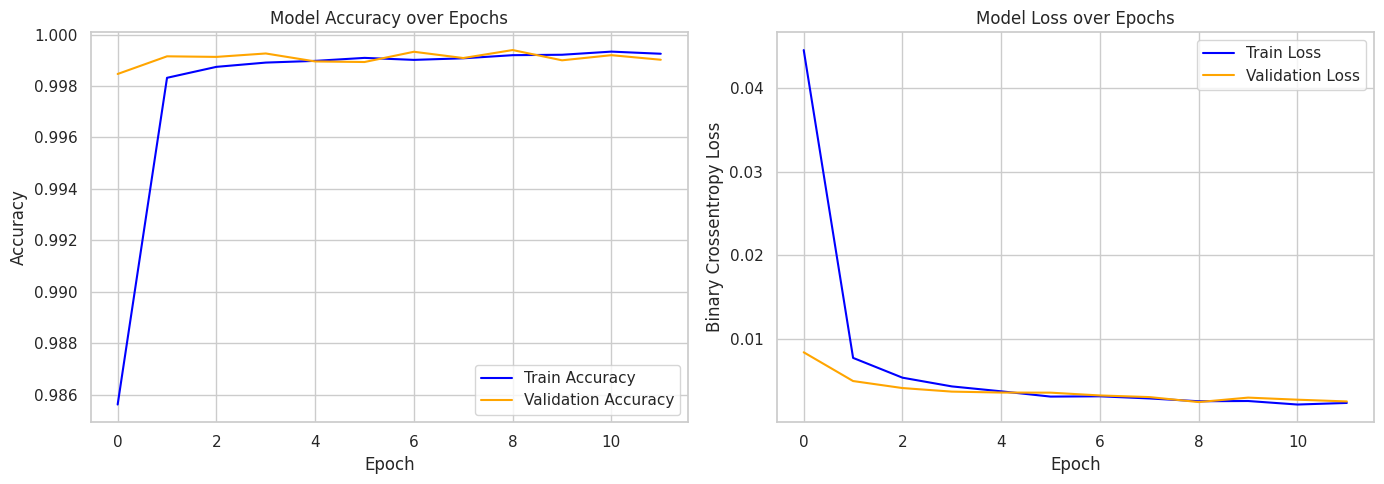

In [ ]:
# --- Visualizing Training Results ---
import matplotlib.pyplot as plt

print("="*50)
print("4. LEARNING CURVES")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Plot 2: Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Binary Crossentropy Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# After this, you can run the evaluation metrics (Classification Report, MCC)
# that we defined in earlier steps on the test_dataset!

CRITICAL EVALUATION: MODEL METRICS
Generating predictions on the test set...
353/353 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step

Classification Report (Edge-Detect):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19534
           1       1.00      1.00      1.00     25600

    accuracy                           1.00     45134
   macro avg       1.00      1.00      1.00     45134
weighted avg       1.00      1.00      1.00     45134

Matthews Correlation Coefficient (MCC): 0.9988


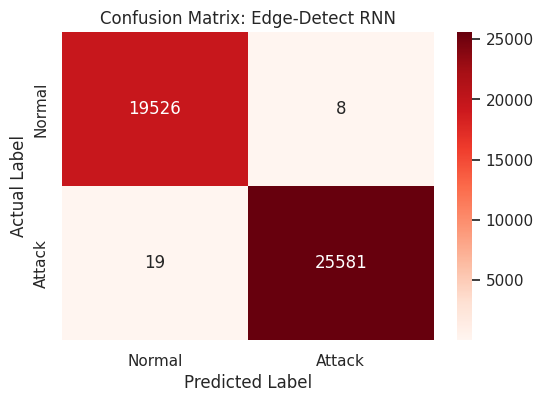


--- Error Analysis Context ---
False Negatives (Missed Attacks): 19
False Positives (False Alarms): 8


In [ ]:
# --- Critical Evaluation & Predictions ---
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("="*50)
print("CRITICAL EVALUATION: MODEL METRICS")
print("="*50)

# 1. Generate probabilities using the sliding window test set
print("Generating predictions on the test set...")
y_pred_probs = model.predict(test_dataset)

# 2. Convert probabilities to binary class labels (Threshold = 0.5)
# Because the output layer uses 'sigmoid', values > 0.5 are classified as 'Attack' (1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 3. We must extract the true labels from the test dataset to match the sliding window shift.
# In Cell 11, we defined the targets as y_test.values[T-1:]
# We need to grab those exact true labels for the evaluation metrics
y_true = y_test.values[T-1:]

# Ensure the lengths match before calculating metrics
if len(y_true) == len(y_pred):
    # --- Classification Report ---
    print("\nClassification Report (Edge-Detect):")
    print(classification_report(y_true, y_pred))

    # --- Matthews Correlation Coefficient (MCC) ---
    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    plt.title('Confusion Matrix: Edge-Detect RNN')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # --- Cybersecurity Error Analysis ---
    fn = cm[1][0]
    fp = cm[0][1]
    print("\n--- Error Analysis Context ---")
    print(f"False Negatives (Missed Attacks): {fn}")
    print(f"False Positives (False Alarms): {fp}")
else:
    print(f"Length mismatch error: y_true ({len(y_true)}) vs y_pred ({len(y_pred)}). Check the windowing step.")

BASELINE COMPARISON: RANDOM FOREST
Training Random Forest on 2D tabular data...
Generating predictions on the test set...

Classification Report (Random Forest Baseline):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19538
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143

Matthews Correlation Coefficient (MCC): 0.9998


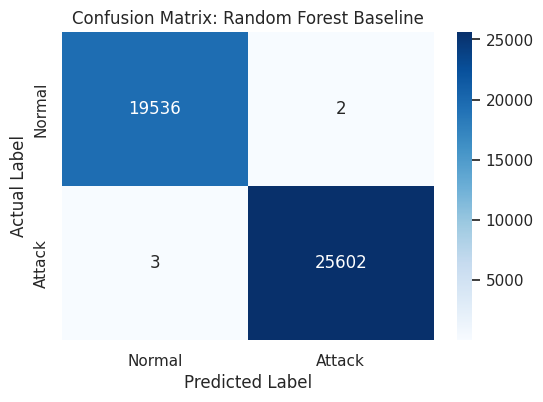


--- Error Analysis Context (Random Forest) ---
False Negatives (Missed Attacks): 3
False Positives (False Alarms): 2


In [ ]:
# --- Baseline Model (Random Forest) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef
import seaborn as sns
import matplotlib.pyplot as plt

print("="*50)
print("BASELINE COMPARISON: RANDOM FOREST")
print("="*50)

# 1. Initialize and Train the Random Forest
print("Training Random Forest on 2D tabular data...")
# n_jobs=-1 uses all available CPU cores to speed up training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# 2. Generate Predictions
print("Generating predictions on the test set...")
rf_preds = rf_model.predict(X_test_scaled)

# 3. Evaluation Metrics
print("\nClassification Report (Random Forest Baseline):")
print(classification_report(y_test, rf_preds))

mcc_rf = matthews_corrcoef(y_test, rf_preds)
print(f"Matthews Correlation Coefficient (MCC): {mcc_rf:.4f}")

# 4. Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix: Random Forest Baseline')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 5. Cybersecurity Error Analysis
fn_rf = cm_rf[1][0]
fp_rf = cm_rf[0][1]
print("\n--- Error Analysis Context (Random Forest) ---")
print(f"False Negatives (Missed Attacks): {fn_rf}")
print(f"False Positives (False Alarms): {fp_rf}")

We see that the Random Forest model performed even better on the whole dataset. Since the prevelance is far from being realisitic, we cannot deduce anything about the performance of the model in real scenarios. To do that we can check the performance on more focused datasets with realistic prevelance.

The sliding window technique doesn't seem to help predictions. However, the proposed model may have an edge if there is:

- Faster inference than random forest, using low computational resources


We cannot simulate it with the absolute highest accuracy to the Raspberry Pi framweork mentioned in the paper, but we can measure how long inference takes in comparison to the Random Forest model we have trained.

In [ ]:
# --- Edge Resource Benchmarking ---
import time
import os
import joblib

print("="*50)
print("COMPUTATIONAL RESOURCE BENCHMARK")
print("="*50)

# ---------------------------------------------------------
# 1. Random Forest Benchmark
# ---------------------------------------------------------
print("Benchmarking Random Forest...")
start_time_rf = time.time()
rf_model.predict(X_test_scaled)
end_time_rf = time.time()

rf_total_time = end_time_rf - start_time_rf
rf_latency_per_sample = (rf_total_time / len(X_test_scaled)) * 1000 # in milliseconds

# Save to disk to measure footprint
joblib.dump(rf_model, 'rf_baseline.pkl')
rf_size_mb = os.path.getsize('rf_baseline.pkl') / (1024 * 1024)

# ---------------------------------------------------------
# 2. Edge-Detect RNN Benchmark
# ---------------------------------------------------------
print("Benchmarking Edge-Detect RNN...")
start_time_rnn = time.time()
model.predict(test_dataset, verbose=0)
end_time_rnn = time.time()

rnn_total_time = end_time_rnn - start_time_rnn
# Divide by the number of windows to get per-window latency
rnn_latency_per_sample = (rnn_total_time / len(y_true)) * 1000 # in milliseconds

# Save to disk to measure footprint
model.save('rnn_edge.h5')
rnn_size_mb = os.path.getsize('rnn_edge.h5') / (1024 * 1024)

# ---------------------------------------------------------
# 3. Results Output
# ---------------------------------------------------------
print("\n" + "="*50)
print("FINAL EDGE DEPLOYMENT RESULTS")
print("="*50)
print(f"Random Forest Footprint:  {rf_size_mb:.2f} MB")
print(f"Edge-Detect Footprint:    {rnn_size_mb:.2f} MB")
print("-" * 50)
print(f"Random Forest Latency:    {rf_latency_per_sample:.4f} ms / packet")
print(f"Edge-Detect Latency:      {rnn_latency_per_sample:.4f} ms / window")

COMPUTATIONAL RESOURCE BENCHMARK
Benchmarking Random Forest...
Benchmarking Edge-Detect RNN...



FINAL EDGE DEPLOYMENT RESULTS
Random Forest Footprint:  1.33 MB
Edge-Detect Footprint:    0.16 MB
--------------------------------------------------
Random Forest Latency:    0.0124 ms / packet
Edge-Detect Latency:      0.4613 ms / window


We see that Random Forest uses a lot more memory, but is significantly faster.

The main conclusion from this about the advantage of the proposed model is the ability to perform in low-memory environments, although it would not be the fastest.